In [1]:
import os, math, random, glob
import numpy as np
import cv2
import torch
import torch.nn as nn
import torchinfo
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


#### Synthetic dataset preparation and visualization

##### Helper functions for colors and noise generation

In [3]:
def get_random_color() -> list[int]:
    return np.random.randint(5, 225, size=3).tolist()


def check_contrast(background, foreground) -> list[int]:
    while abs(np.mean(background) - np.mean(foreground)) < 50:  # min contrast threshold id 50
        foreground = get_random_color()
    return foreground


def add_gauss_noise(image) -> np.ndarray:
    noise = np.random.normal(0, 10, image.shape).astype(np.float32)
    image = np.clip(image.astype(np.float32) + noise, 0, 255)  #
    blurred = cv2.GaussianBlur(image, (3, 3), 0)
    return blurred.astype(np.uint8)


def is_far_enough(point, existing_points, distance) -> bool:
    for x, y in existing_points:
        dx = point[0] - x  #
        dy = point[1] - y

        if (dx ** 2 + dy ** 2) < distance ** 2:
            return False

    return True

##### Generating simple shapes
Triangle - 3 random points cv2.fillPoly()

Quadrilateral - 4 random points and call cv2.fillPoly()

Star - 1 random point in the center and 5 random outer points (use a min distance)

In [4]:
def get_triangle_points(width, height, distance) -> list[list[int]]:
    triangle_points = []

    while len(triangle_points) < 3:
        x = np.random.randint(5, width - 5)  #
        y = np.random.randint(5, height - 5)

        if is_far_enough([x, y], triangle_points, distance):
            triangle_points.append([x, y])

    return triangle_points


def get_quadrilateral_points(width, height) -> list[list[int]]:
    x1 = np.random.randint(40, width - 120)  # todo why these num
    y1 = np.random.randint(40, height - 120)

    w = np.random.randint(40, 120)
    h = np.random.randint(40, 120)  # todo

    quadrilateral_points = [  # should i check is it far enough
        [x1, y1],
        [x1 + w, y1],
        [x1 + w, y1 + h],
        [x1, y1 + h]
    ]

    for point in quadrilateral_points:
        point[0] += np.random.randint(-25, 25)
        point[1] += np.random.randint(-25, 25)  # todo do we even need this

        point[0] = max(5, min(point[0], width - 5))  #keep the points in the image
        point[1] = max(5, min(point[1], height - 5))

    return quadrilateral_points


def get_star_points(width, height, distance) -> list[list[int]]:
    center_x = np.random.randint(80, width - 80)  # why 80
    center_y = np.random.randint(80, height - 80)

    star_points = [[center_x, center_y]]

    while len(star_points) < 6:
        x = center_x + np.random.randint(-80, 80)
        y = center_y + np.random.randint(-80, 80)

        x = max(5, min(x, width - 5))  # keep th epoints in the image
        y = max(5, min(y, height - 5))

        if is_far_enough([x, y], star_points, distance):
            star_points.append([x, y])

    return star_points

##### Generate complex shapes
Checkerboard - 3x4 grid where each cell is different color from the cell that is sticked to. Keypoints are all the corner's intersections (where different colors meet)

3D cube - pick 1 center point, 3 inner points that are connected to the center(star) and 3 outter points that are edges and connecting to inner points. Then draw 3 quatrilaterals to make it look like 3D cude

In [5]:
def get_checkerboard_points(image, width, height, rows=3, cols=4):
    checkerboard_w = np.random.randint(100, 200)
    checkerboard_h = np.random.randint(100, 200)

    x0 = np.random.randint(20, width - checkerboard_w - 20)
    y0 = np.random.randint(20, height - checkerboard_h - 20)

    cell_w = checkerboard_w // cols
    cell_h = checkerboard_h // rows

    colors = [get_random_color(), None]
    colors[1] = check_contrast(colors[0], get_random_color())

    # grid corners: (rows+1) x (cols+1) = 4 x 5 = 20 keypoints
    checkerboard_points = []
    for row in range(rows + 1):
        for col in range(cols + 1):
            x = x0 + col * cell_w
            y = y0 + row * cell_h
            checkerboard_points.append([x, y])

    # draw cells
    for row in range(rows):
        for col in range(cols):
            x = x0 + col * cell_w
            y = y0 + row * cell_h
            cv2.rectangle(image, (x, y), (x + cell_w, y + cell_h), colors[(row + col) % 2], -1)

    return checkerboard_points, (x0, y0, checkerboard_w, checkerboard_h)


def get_3d_cube(image, width, height) -> list[list[int]]:
    center_x = np.random.randint(60, width - 60)
    center_y = np.random.randint(60, height - 60)

    base_angle = np.random.uniform(0, 2 * np.pi)

    inner_points = []
    for step in range(3):
        angle = base_angle + step * (2 * np.pi / 3)
        distance = np.random.randint(30, 80)
        x = int(np.clip(center_x + distance * np.cos(angle), 5, width - 5))
        y = int(np.clip(center_y + distance * np.sin(angle), 5, height - 5))
        inner_points.append([x, y])

    outer_points = []
    for i in range(3):
        point_a = inner_points[i]
        point_b = inner_points[(i + 1) % 3]
        mid_x = (point_a[0] + point_b[0]) / 2
        mid_y = (point_a[1] + point_b[1]) / 2
        push_factor = np.random.uniform(1.2, 1.8)  #
        outer_x = int(np.clip(center_x + (mid_x - center_x) * push_factor, 5, width - 5))
        outer_y = int(np.clip(center_y + (mid_y - center_y) * push_factor, 5, height - 5))
        outer_points.append([outer_x, outer_y])

    center = [center_x, center_y]
    I1, I2, I3 = inner_points
    O12, O23, O31 = outer_points

    faces = [[center, I1, O12, I2], [center, I2, O23, I3], [center, I3, O31, I1]]
    for face in faces:
        arr = np.array(face, np.int32)
        cv2.fillPoly(image, [arr], get_random_color())
        cv2.polylines(image, [arr], True, (0, 0, 0), 2)

    return [center] + inner_points + outer_points



##### Generate images

In [6]:
def generate_image_with_shape(shape, width, height):
    background = get_random_color()
    image = np.full((height, width, 3), background, np.uint8)  #
    foreground = check_contrast(background, get_random_color())

    if shape == 'triangle':
        keypoints = get_triangle_points(width, height, 20)
        cv2.fillPoly(image, [np.array(keypoints, np.int32)], foreground)  #
    elif shape == 'quadrilateral':
        keypoints = get_quadrilateral_points(width, height)
        cv2.fillPoly(image, [np.array(keypoints, np.int32)], foreground)
    elif shape == 'star':
        keypoints = get_star_points(width, height, 20)
        for point in keypoints[1:]:  # draw lines from center to each outer point
            cv2.line(image, tuple(map(int, keypoints[0])), tuple(map(int, point)), foreground, 2)
    elif shape == 'chessboard':
        keypoints, box = get_checkerboard_points(image, width, height)
    elif shape == 'cube':
        keypoints = get_3d_cube(image, width, height)
    else:
        raise ValueError(shape)

    return add_gauss_noise(image), keypoints


def generate_image_with_more_shapes(width, height, num_shapes) -> tuple[np.ndarray, list[list[int]]]:
    background = get_random_color()
    image = np.full((height, width, 3), background, np.uint8)
    occupied_part = np.zeros((height, width), np.uint8)
    keypoints_in_image = []

    for _ in range(num_shapes):
        for _ in range(20):
            shape_type = np.random.choice(['triangle', 'quadrilateral', 'star'])

            if shape_type == 'triangle':
                points = get_triangle_points(width, height, distance=20)
            elif shape_type == 'quadrilateral':
                points = get_quadrilateral_points(width, height)
            else:
                points = get_star_points(width, height, distance=20)

            temp_mask = np.zeros_like(occupied_part)
            if shape_type == 'star':
                for point in points[1:]:
                    cv2.line(temp_mask, tuple(map(int, points[0])), tuple(map(int, point)), 255, 3)
            else:
                cv2.fillPoly(temp_mask, [np.array(points, np.int32)], 255)

            if np.any(occupied_part & temp_mask):
                continue  # overlaps, try again

            # no overlap, draw it
            color = check_contrast(background, get_random_color())
            if shape_type == 'star':
                for point in points[1:]:
                    cv2.line(image, tuple(map(int, points[0])), tuple(map(int, point)), color, 2)
            else:
                cv2.fillPoly(image, [np.array(points, np.int32)], color)

            occupied_part |= temp_mask
            keypoints_in_image.extend(points)
            break

    return add_gauss_noise(image), keypoints_in_image


##### Homography augmentation
This should happen during data generation and durng homographic adaptation

In [7]:
def generate_random_homography(width, height, min_distance=80) -> np.ndarray:
    center_x = width // 2
    center_y = height // 2

    quadrants = [
        (0, center_x, 0, center_y),  # top-left
        (center_x, width, 0, center_y),  # top-right
        (center_x, width, center_y, height),  # bottom-right
        (0, center_x, center_y, height),  # bottom-left
    ]

    original_points = []
    for x_min, x_max, y_min, y_max in quadrants:
        while True:
            x = np.random.randint(x_min, x_max)
            y = np.random.randint(y_min, y_max)
            if is_far_enough([x, y], [[center_x, center_y]], min_distance):
                original_points.append([x, y])
                break

    # random rotation by shifting points (0, 90, 180, or 270 degrees)
    original_points = np.roll(original_points, shift=np.random.randint(0, 4), axis=0)

    original = np.array(original_points, np.float32)
    transformed = np.array([[0, 0], [width - 1, 0], [width - 1, height - 1], [0, height - 1]], np.float32)  #

    return cv2.getPerspectiveTransform(original, transformed)


def apply_homography(image, keypoints, width,
                     height):  #Without this, your image would be warped but your keypoints would still be at the old positions — they'd be pointing to the wrong locations:
    homography = generate_random_homography(width, height)

    warped_image = cv2.warpPerspective(image, homography, (width, height))

    warped_keypoints = []
    for x, y in keypoints:
        point = np.array([x, y, 1], dtype=np.float32)
        transformed = homography @ point  ####### matrix multiplication where we have homogeneous coordinate
        new_x = transformed[0] / transformed[2]  # divide by w
        new_y = transformed[1] / transformed[2]

        # only points inside the image
        if 0 <= new_x < width and 0 <= new_y < height:
            warped_keypoints.append([int(new_x), int(new_y)])

    return warped_image, warped_keypoints


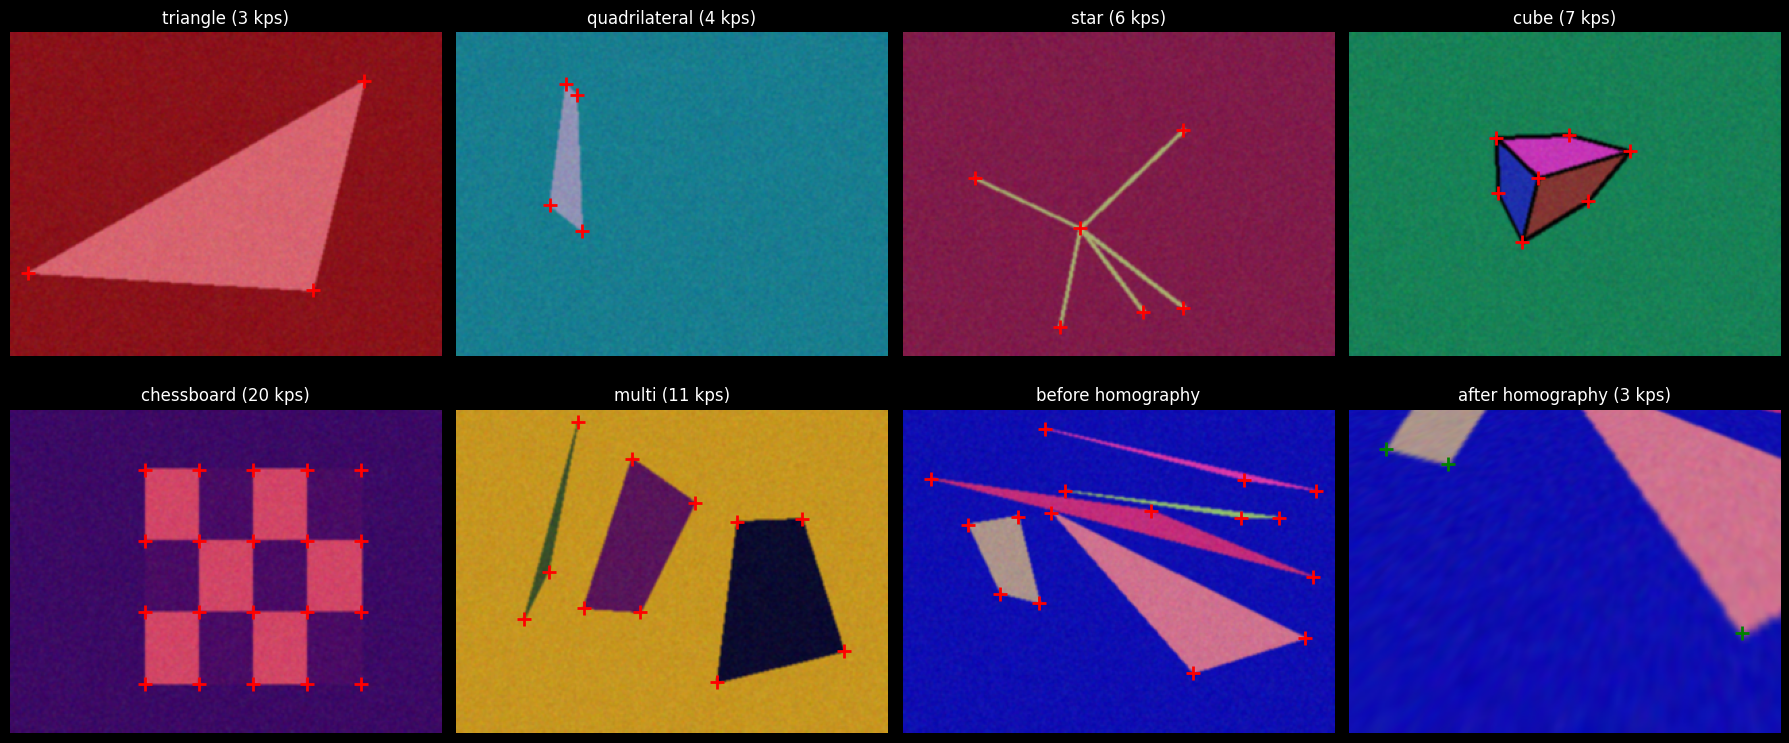

In [8]:
def show_sample_grid():
    IMG_W, IMG_H = 320, 240
    fig, axs = plt.subplots(2, 4, figsize=(18, 8))

    for ax, s in zip(axs[0], ['triangle', 'quadrilateral', 'star', 'cube']):
        img, kps = generate_image_with_shape(s, IMG_W, IMG_H)
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        for x, y in kps:
            ax.plot(x, y, 'r+', ms=10, mew=2)
        ax.set_title(f'{s} ({len(kps)} kps)')
        ax.axis('off')

    img, kps = generate_image_with_shape('chessboard', IMG_W, IMG_H)
    axs[1, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    for x, y in kps:
        axs[1, 0].plot(x, y, 'r+', ms=10, mew=2)
    axs[1, 0].set_title(f'chessboard ({len(kps)} kps)')
    axs[1, 0].axis('off')

    img, kps = generate_image_with_more_shapes(IMG_W, IMG_H, 5)
    axs[1, 1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    for x, y in kps:
        axs[1, 1].plot(x, y, 'r+', ms=10, mew=2)
    axs[1, 1].set_title(f'multi ({len(kps)} kps)')
    axs[1, 1].axis('off')

    img, kps = generate_image_with_more_shapes(IMG_W, IMG_H, 5)
    img2, kps2 = apply_homography(img, kps, IMG_W, IMG_H)
    axs[1, 2].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    for x, y in kps:
        axs[1, 2].plot(x, y, 'r+', ms=10, mew=2)
    axs[1, 2].set_title('before homography')
    axs[1, 2].axis('off')

    axs[1, 3].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
    for x, y in kps2:
        axs[1, 3].plot(x, y, 'g+', ms=10, mew=2)
    axs[1, 3].set_title(f'after homography ({len(kps2)} kps)')
    axs[1, 3].axis('off')

    plt.tight_layout()
    plt.show()


show_sample_grid()


#### Neural Network
Building neurla network that has encoder and decoder

##### ResNet block
ResNet block is built from Conv - BatchNorm - ReLu - Conv - BatchNorm - ReLu. Its key idea is the skip connection (residual connection), where the input is added to the output of the block.
If the number of input and output channels is different, a 1×1 convolution is used to match dimensions before the addition.
This skip connection helps prevent vanishing gradients and makes training deep networks more stable. The skip connection preserves the original signal and improves gradient flow, making it easier for the network to learn useful transformations.

In [9]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.convolution1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.batchNorm1 = nn.BatchNorm2d(out_channels)
        self.convolution2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.batchNorm2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        if in_channels != out_channels:
            self.identity = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, bias=False)
        else:
            self.identity = nn.Identity()

    def forward(self, x):
        identity = self.identity(x)
        out = self.convolution1(x)
        out = self.batchNorm1(out)
        out = self.relu(out)
        out = self.convolution2(out)
        out = self.batchNorm2(out)
        out += identity
        out = self.relu(out)

        return out

##### Encoder
The encoder is built from 3x(ResNet block -> MaxPoll) and at the end 2xResNet block.

The output from the encoder for a 240x320 image is 30 x 40 x 128. Each pixel in this 30x40 output coresponds to an 8x8 region in the original image (240/30 = 8 and 320/40 = 8) and each of these 128 values decribes everything the newtwork saw in that 8x8 patch of the original images. Then the decoder uses these vectors to decide if there was a keypoint in this 8x8 cell and if yes where?

In [10]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.body = nn.Sequential(
            ResNetBlock(1, 64),  # input is grayscale → 64 channels image is 240x320
            ResNetBlock(64, 64),
            nn.MaxPool2d(2),

            ResNetBlock(64, 64),
            ResNetBlock(64, 64),
            nn.MaxPool2d(2),

            ResNetBlock(64, 128),
            ResNetBlock(128, 128),
            nn.MaxPool2d(2),

            ResNetBlock(128, 128),
            ResNetBlock(128, 128),
        )

    def forward(self, x):
        return self.body(x)

##### Decoder
The decoder is built from Conv(128 -> 256), BatchNorm, ReLu and Conv(256 -> 65)

The output of the decoder is (B, 65, H/8, W/8) logits, used for training.  The 65 are 64 possible positions withing the 8x8  cells and  +1 cell with no keypoint

In [11]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 65, kernel_size=1, bias=False),
        )

    def forward(self, x):
        return self.body(x)

##### SuperPoint detector
The model will return logits that will be used to train, then when using the model the output from the model should be set  under softmax, the last channel (65th) should be dropped  and the 64 channels should be rearranged, to get full HxW heatmap

In [12]:
class SuperPointDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)  #

        # convert to full resolution heatmap (used for inference only)
        # x = torch.softmax(x, dim=1)  # softmax over 65 channels
        # x = x[:, :-1, :, :]          # drop the 65th "no keypoint" channel → (B, 64, H/8, W/8)
        # x = nn.PixelShuffle(8)(x)    # rearrange 64 channels → full H x W heatmap  todo after trainig when using the mdeol
        return x  # (B, 1, H, W)

In [13]:
model = SuperPointDetector().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999))
writer = SummaryWriter('runs/superpoint')

print(torchinfo.summary(model, [1, 1, 240, 320], device=device,
                        depth=4,
                        col_names=("input_size", "output_size", "num_params", "mult_adds"),
                        ))

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Mult-Adds
SuperPointDetector                       [1, 1, 240, 320]          [1, 65, 30, 40]           --                        --
├─Encoder: 1-1                           [1, 1, 240, 320]          [1, 128, 30, 40]          --                        --
│    └─Sequential: 2-1                   [1, 1, 240, 320]          [1, 128, 30, 40]          --                        --
│    │    └─ResNetBlock: 3-1             [1, 1, 240, 320]          [1, 64, 240, 320]         --                        --
│    │    │    └─Conv2d: 4-1             [1, 1, 240, 320]          [1, 64, 240, 320]         64                        4,915,200
│    │    │    └─Conv2d: 4-2             [1, 1, 240, 320]          [1, 64, 240, 320]         576                       44,236,800
│    │    │    └─BatchNorm2d: 4-3        [1, 64, 240, 320]         [1, 64, 240, 320]         128                       128
│

#### Synthetic Dataset

In [14]:
def keypoints_to_grid(mask: np.ndarray) -> np.ndarray:
    height, width = mask.shape
    height_cell, width_cell = height // 8, width // 8

    # split full mask into 8x8 cells and flatten each cell to 64 positions
    m = mask.reshape(height_cell, 8, width_cell, 8)       # (Hc, 8, Wc, 8)
    m = np.transpose(m, (0, 2, 1, 3))    # (Hc, Wc, 8, 8) - group each cell together
    m = m.reshape(height_cell, width_cell, 64)            # (Hc, Wc, 64)   - flatten 8x8 → 64 positions

    # start with all dustbins set (assume no keypoint in any cell)
    grid = np.zeros((height_cell, width_cell, 65), dtype=np.float32)
    grid[..., 64] = 1.0

    # for each cell, check if there are any keypoints
    for i in range(height_cell):
        for j in range(width_cell):
            keypoint_positions = np.where(m[i, j] > 0)[0]  # which of 64 positions are set

            if len(keypoint_positions) > 0:
                # if multiple keypoints in same cell, keep one randomly
                keep = np.random.choice(keypoint_positions)
                grid[i, j, :] = 0         # clear dustbin
                grid[i, j, keep] = 1.0    # set the chosen keypoint position

    return grid

In [15]:
class SyntheticDataset(Dataset):
    def __init__(self, width=320, height=240, homography_probability = 0.7): #
        self.width = width
        self.height = height
        self.homography_probability = homography_probability

    def generate_random_sample(self):
        mode = np.random.choice(['simple', 'complex', 'multi'], p=[0.4, 0.4, 0.2])

        if mode == 'simple':
            shape = np.random.choice(['triangle', 'quadrilateral', 'star'])
            return generate_image_with_shape(shape, self.width, self.height)
        elif mode == 'complex':
            shape = np.random.choice(['chessboard', 'cube'])
            return generate_image_with_shape(shape, self.width, self.height)
        else:
            return generate_image_with_more_shapes(self.width, self.height, 4)

    def __len__(self):
        return 9999999 # infinite

    def __getitem__(self, idx):
        # image with keypoints
        image, keypoints = self.generate_random_sample()

        # randomly apply homography augmentation
        if np.random.rand() < self.homography_probability:
            image, keypoints = apply_homography(image, keypoints, self.width, self.height)

        # convert image to grayscale float tensor (1, H, W)
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
        image_tensor = torch.from_numpy(gray).unsqueeze(0)

        # convert keypoints to binary mask (H, W)
        mask = np.zeros((self.height, self.width), dtype=np.float32)
        for x, y in keypoints:
            if 0 <= x < self.width and 0 <= y < self.height:
                mask[int(y), int(x)] = 1.0

        # convert mask to training label (65, Hc, Wc)
        label = keypoints_to_grid(mask)
        label_tensor = torch.from_numpy(label).permute(2, 0, 1).float()

        return image_tensor, label_tensor


#### Training, loss and visualization

##### Loss
For los is used cross entropy using logits (pre softmax values)

In [16]:
def loss_fun(logits, target):
    higest_index = torch.argmax(target, dim=1)
    return F.cross_entropy(logits, higest_index)

##### Training


In [17]:
MAX_ITERS = 200000
BATCH_SIZE = 8
PRINT_EVERY = 100

dataset = SyntheticDataset(320, 240, homography_probability=0.7)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                    num_workers=0, drop_last=True)

model = SuperPointDetector().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999))

loss_history = []
best_loss = float('inf')
iteration = 0
model.train()

while iteration < MAX_ITERS:
    for img, target in loader:
        img = img.to(device); target = target.to(device)
        optimizer.zero_grad()
        logits = model(img)
        loss = loss_fun(logits, target)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())

        if iteration % PRINT_EVERY == 0:
            print(f'[Iteration {iteration:5d}]| Loss: {loss.item():.4f}  Best Loss={best_loss:.4f}')

        if loss.item() < best_loss:
            best_loss = loss.item()
            torch.save({'model_state_dict': model.state_dict(),
                        'iteration': iteration,
                        'loss': best_loss}, 'models/model_best.pth')

        iteration += 1
        if iteration >= MAX_ITERS:
            break

torch.save({'model_state_dict': model.state_dict(),
            'iteration': iteration,
            'loss_history': loss_history}, 'models/model_final.pth')

print(f'\ndone. best loss = {best_loss:.4f}')

[    0] loss=4.4428  best=inf
[  100] loss=0.0548  best=0.0380
[  200] loss=0.0533  best=0.0227
[  300] loss=0.0191  best=0.0224
[  400] loss=0.0290  best=0.0175
[  500] loss=0.0280  best=0.0172
[  600] loss=0.0383  best=0.0115
[  700] loss=0.0282  best=0.0101
[  800] loss=0.0167  best=0.0101
[  900] loss=0.0299  best=0.0101
[ 1000] loss=0.0194  best=0.0101
[ 1100] loss=0.0254  best=0.0101
[ 1200] loss=0.0286  best=0.0095
[ 1300] loss=0.0219  best=0.0066
[ 1400] loss=0.0223  best=0.0066
[ 1500] loss=0.0175  best=0.0066
[ 1600] loss=0.0256  best=0.0066
[ 1700] loss=0.0075  best=0.0066
[ 1800] loss=0.0166  best=0.0066
[ 1900] loss=0.0152  best=0.0066
[ 2000] loss=0.0188  best=0.0066
[ 2100] loss=0.0161  best=0.0065
[ 2200] loss=0.0168  best=0.0044
[ 2300] loss=0.0134  best=0.0044
[ 2400] loss=0.0179  best=0.0044
[ 2500] loss=0.0157  best=0.0044
[ 2600] loss=0.0225  best=0.0044
[ 2700] loss=0.0185  best=0.0044
[ 2800] loss=0.0164  best=0.0044
[ 2900] loss=0.0140  best=0.0044
[ 3000] loss=

##### Loss visualization

In [18]:
def plot_loss(loss_history, smoothing_window=100):
    loss = np.array(loss_history, dtype=float)

    # calculate smoothed loss using a sliding window average
    if len(loss) >= smoothing_window:
        smoothed = np.convolve(loss, np.ones(smoothing_window) / smoothing_window, mode='valid')
        smoothed_start = smoothing_window - 1
    else:
        smoothed = loss
        smoothed_start = 0

    plt.figure(figsize=(10, 5))
    plt.plot(loss, alpha=0.4, label='Raw loss')
    plt.plot(range(smoothed_start, smoothed_start + len(smoothed)), smoothed, label=f'Smoothed (window={smoothing_window})')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.title('SuperPoint Training Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

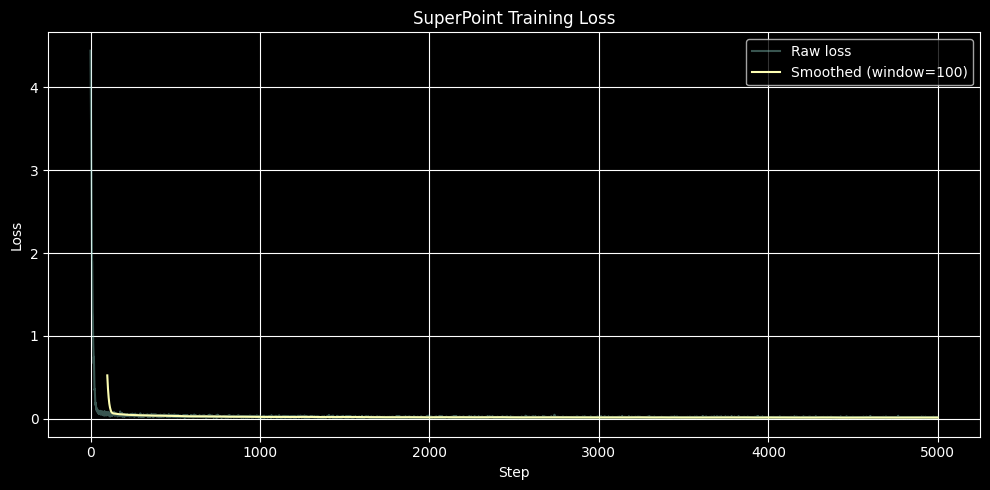

In [19]:
plot_loss(loss_history)

#### Results visualization


In [20]:
def logits_to_heatmap(logits):
    batch_size, _, height_cells, width_cells = logits.shape

    probabilities = F.softmax(logits, dim=1)[:, :-1]                        # drop dustbin → (B, 64, Hc, Wc)
    probabilities = probabilities.view(batch_size, 8, 8, height_cells, width_cells)
    probabilities = probabilities.permute(0, 3, 1, 4, 2)                    # (B, Hc, 8, Wc, 8)
    heatmap = probabilities.reshape(batch_size, 1, height_cells * 8, width_cells * 8)

    return heatmap

def get_keypoints_from_heatmap(heatmap, percentile=99.5, nms_radius=4, max_keypoints=500):
    prob_map = heatmap[0, 0].cpu().numpy()

    # threshold - only keep top percentile of responses
    threshold = float(np.percentile(prob_map, percentile))
    above_threshold = prob_map > threshold

    if above_threshold.sum() == 0:
        return [], prob_map

    # non-maximum suppression - only keep local maxima
    kernel_size = 2 * nms_radius + 1
    local_max = prob_map == cv2.dilate(prob_map, np.ones((kernel_size, kernel_size), np.uint8))
    keypoint_mask = above_threshold & local_max

    ys, xs = np.where(keypoint_mask)
    if len(xs) == 0:
        return [], prob_map

    # sort by score and keep top max_keypoints
    scores = prob_map[ys, xs]
    top_indices = np.argsort(-scores)[:max_keypoints]
    keypoints = [(int(xs[i]), int(ys[i])) for i in top_indices]

    return keypoints, prob_map

def load_model(path='superpoint_final.pth'):
    checkpoint = torch.load(path, map_location=device)
    model = SuperPointDetector().to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(f'loaded model from {path} (epoch={checkpoint.get("epoch")}, loss={checkpoint.get("loss_history", [0])[-1]:.4f})')
    return model

##### Predictions on synthetic samples

In [21]:
def show_predictions(model, num_samples=4):
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4 * num_samples))

    for row in range(num_samples):
        image, ground_truth_keypoints = generate_image_with_more_shapes(320, 240, 4)
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
        image_tensor = torch.from_numpy(gray).unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            logits = model(image_tensor)
            heatmap = logits_to_heatmap(logits)

        predicted_keypoints, prob_map = get_keypoints_from_heatmap(heatmap)

        # ground truth
        axes[row, 0].imshow(gray, cmap='gray')
        for x, y in ground_truth_keypoints:
            axes[row, 0].plot(x, y, 'r+', ms=8, mew=1.5)
        axes[row, 0].set_title(f'Ground truth ({len(ground_truth_keypoints)} keypoints)')
        axes[row, 0].axis('off')

        # heatmap
        axes[row, 1].imshow(prob_map, cmap='jet')
        axes[row, 1].set_title('Heatmap')
        axes[row, 1].axis('off')

        # predictions
        axes[row, 2].imshow(gray, cmap='gray')
        for x, y in predicted_keypoints:
            axes[row, 2].plot(x, y, 'g+', ms=8, mew=1.5)
        axes[row, 2].set_title(f'Predicted ({len(predicted_keypoints)} keypoints)')
        axes[row, 2].axis('off')

    plt.tight_layout()
    plt.show()

#### Homographic adaptation

In [22]:
def homographic_adaptation(model, grayscale_image, num_homographies=99):
    height, width = grayscale_image.shape
    accumulated_heatmap = np.zeros((height, width), dtype=np.float32)
    count_map = np.zeros((height, width), dtype=np.float32)
    ones = np.ones((height, width), dtype=np.float32)

    # include original image prediction
    image_tensor = torch.from_numpy(grayscale_image).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        accumulated_heatmap += logits_to_heatmap(model(image_tensor))[0, 0].cpu().numpy()
    count_map += ones

    # apply random homographies and accumulate predictions
    for _ in range(num_homographies):
        homography = generate_random_homography(width, height)
        warped_image = cv2.warpPerspective(grayscale_image, homography, (width, height))

        warped_tensor = torch.from_numpy(warped_image).unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            warped_heatmap = logits_to_heatmap(model(warped_tensor))[0, 0].cpu().numpy().astype(np.float32)

        inverse_homography = np.linalg.inv(homography).astype(np.float32)
        heatmap_original_space = cv2.warpPerspective(warped_heatmap, inverse_homography, (width, height))
        valid_pixels = cv2.warpPerspective(ones, inverse_homography, (width, height),
                                           flags=cv2.INTER_NEAREST,
                                           borderMode=cv2.BORDER_CONSTANT, borderValue=0.0)

        accumulated_heatmap += heatmap_original_space
        count_map += valid_pixels

    return accumulated_heatmap / np.maximum(count_map, 1e-6)

In [23]:
def get_keypoints_from_probability(probability_map, percentile=99.5, nms_radius=4, max_keypoints=500):
    """Find keypoints as local maxima above a percentile threshold."""
    threshold = float(np.percentile(probability_map, percentile))
    above_threshold = probability_map > threshold

    if above_threshold.sum() == 0:
        return []

    # non-maximum suppression
    kernel_size = 2 * nms_radius + 1
    local_max = probability_map == cv2.dilate(probability_map, np.ones((kernel_size, kernel_size), np.uint8))
    keypoint_mask = above_threshold & local_max

    ys, xs = np.where(keypoint_mask)
    if len(xs) == 0:
        return []

    scores = probability_map[ys, xs]
    top_indices = np.argsort(-scores)[:max_keypoints]
    return [(int(xs[i]), int(ys[i])) for i in top_indices]

#### Demo on real photo

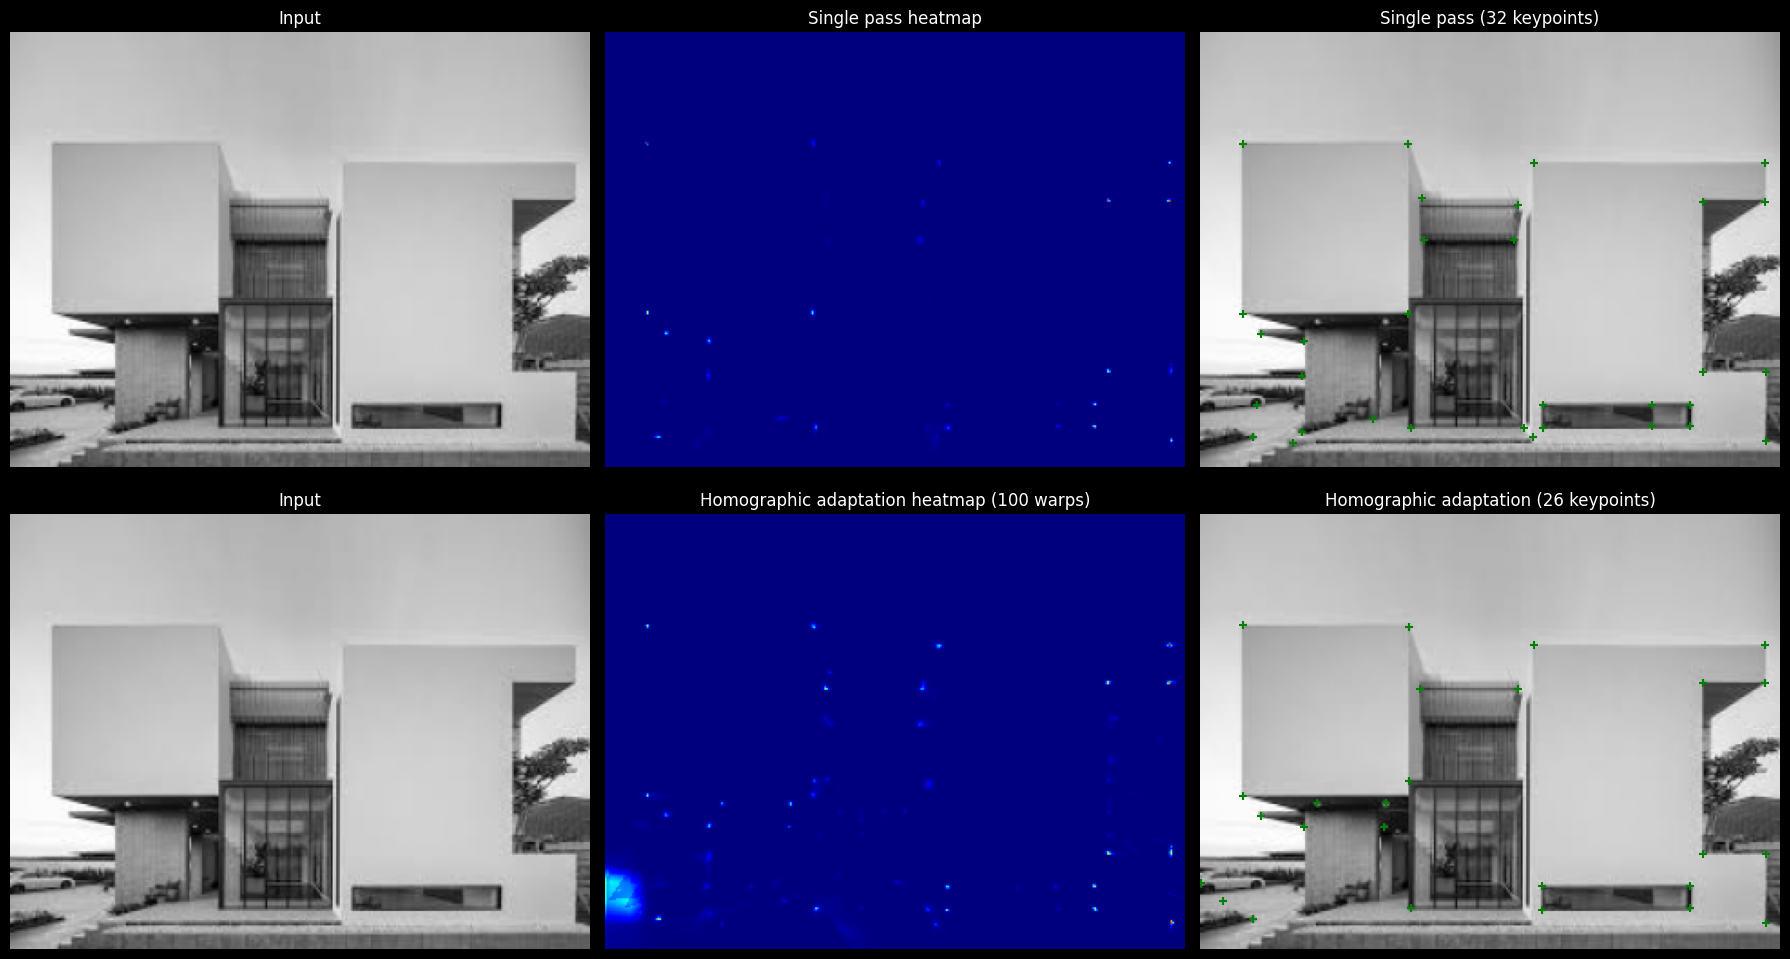

In [24]:
def predict_on_photo(path, model, num_homographies=99, percentile=99.5):
    # load and preprocess image
    image = cv2.imread(path)
    if image is None:
        raise FileNotFoundError(path)
    image = cv2.resize(image, (320, 240  ), interpolation=cv2.INTER_AREA)
    grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0

    # single forward pass
    image_tensor = torch.from_numpy(grayscale).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        single_heatmap = logits_to_heatmap(model(image_tensor))[0, 0].cpu().numpy()

    # homographic adaptation
    adapted_heatmap = homographic_adaptation(model, grayscale, num_homographies=num_homographies)

    # get keypoints from both heatmaps
    single_keypoints = get_keypoints_from_probability(single_heatmap, percentile=percentile)
    adapted_keypoints = get_keypoints_from_probability(adapted_heatmap, percentile=percentile)

    # plot results
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    axes[0, 0].imshow(grayscale, cmap='gray')
    axes[0, 0].set_title('Input')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(single_heatmap, cmap='jet')
    axes[0, 1].set_title('Single pass heatmap')
    axes[0, 1].axis('off')

    axes[0, 2].imshow(grayscale, cmap='gray')
    for x, y in single_keypoints:
        axes[0, 2].plot(x, y, 'g+', ms=6, mew=1.5)
    axes[0, 2].set_title(f'Single pass ({len(single_keypoints)} keypoints)')
    axes[0, 2].axis('off')

    axes[1, 0].imshow(grayscale, cmap='gray')
    axes[1, 0].set_title('Input')
    axes[1, 0].axis('off')

    axes[1, 1].imshow(adapted_heatmap, cmap='jet')
    axes[1, 1].set_title(f'Homographic adaptation heatmap ({num_homographies + 1} warps)')
    axes[1, 1].axis('off')

    axes[1, 2].imshow(grayscale, cmap='gray')
    for x, y in adapted_keypoints:
        axes[1, 2].plot(x, y, 'g+', ms=6, mew=1.5)
    axes[1, 2].set_title(f'Homographic adaptation ({len(adapted_keypoints)} keypoints)')
    axes[1, 2].axis('off')

    plt.tight_layout()
    plt.savefig('real_photo_predictions.png', dpi=120, bbox_inches='tight')
    plt.show()

    return single_keypoints, adapted_keypoints, single_heatmap, adapted_heatmap


single_keypoints, adapted_keypoints, single_heatmap, adapted_heatmap = predict_on_photo(
    'visualization/real_photo.jpg', model, num_homographies=99, percentile=99.5)